In [2]:
import torch


# Or if saved as state_dict
state_base = torch.load("model_base.pth", map_location=torch.device('cpu'))
state_CL = torch.load("model_CL_a10000_l0_1.pth", map_location=torch.device('cpu'))
state_L = torch.load("model_continuous_L_1_all.pth", map_location=torch.device('cpu'))

In [4]:
state_base.keys()

odict_keys(['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.0.bn2.num_batches_tracked', 'layer1.1.conv1.weight', 'layer1.1.bn1.weight', 'layer1.1.bn1.bias', 'layer1.1.bn1.running_mean', 'layer1.1.bn1.running_var', 'layer1.1.bn1.num_batches_tracked', 'layer1.1.conv2.weight', 'layer1.1.bn2.weight', 'layer1.1.bn2.bias', 'layer1.1.bn2.running_mean', 'layer1.1.bn2.running_var', 'layer1.1.bn2.num_batches_tracked', 'layer2.0.conv1.weight', 'layer2.0.bn1.weight', 'layer2.0.bn1.bias', 'layer2.0.bn1.running_mean', 'layer2.0.bn1.running_var', 'layer2.0.bn1.num_batches_tracked', 'layer2.0.conv2.weight', 'layer2.0.bn2.weight', 'layer2.0.bn2.bias', '

In [18]:
diffs_c = {}
diffs_l = {}
for k in list(state_base.keys())[:-2]:

    if "weight" in k or "bias" in k:
        param_b = state_base[k].float()
        param_c = state_CL[k].float()
        param_l = state_L[k].float()

        diffs_c[k] = torch.norm(param_b - param_c).item()
        diffs_l[k] = torch.norm(param_b - param_l).item()

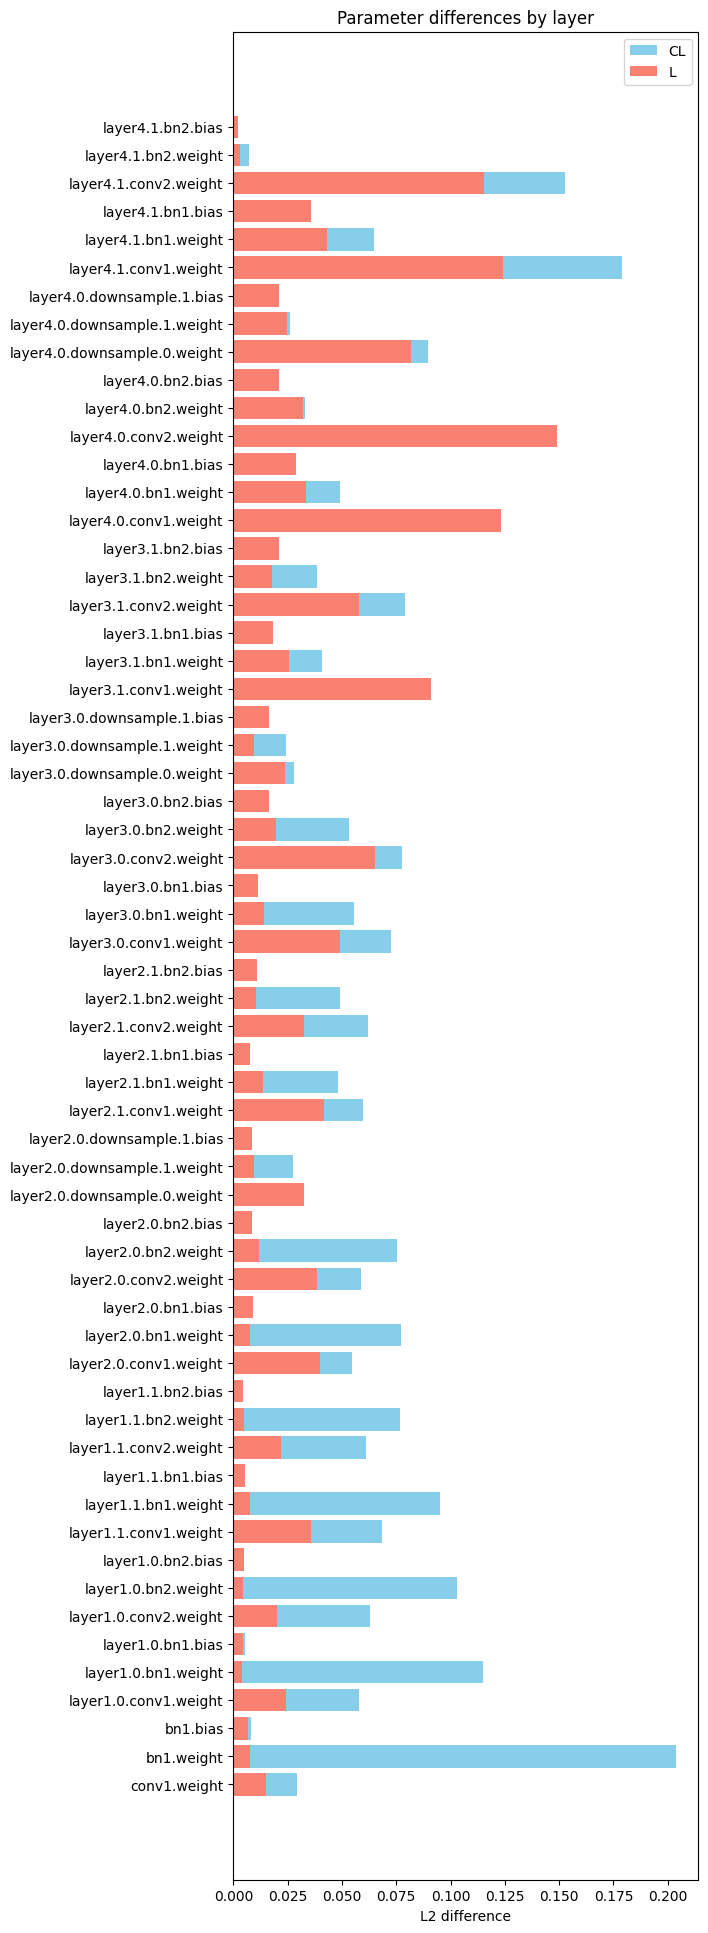

In [30]:
import matplotlib.pyplot as plt

layer_names = list(diffs_c.keys())
layer_values_c = [diffs_c[k] for k in layer_names]
layer_values_l = [diffs_l[k] for k in layer_names]

plt.figure(figsize=(6,24))
plt.barh(layer_names, layer_values_c, label='CL', color="skyblue")
plt.barh(layer_names, layer_values_l, label='L', color="salmon")


plt.xlabel("L2 difference")
plt.title("Parameter differences by layer")
plt.legend()
plt.savefig("param_change_CL.png", dpi=300)
plt.show()


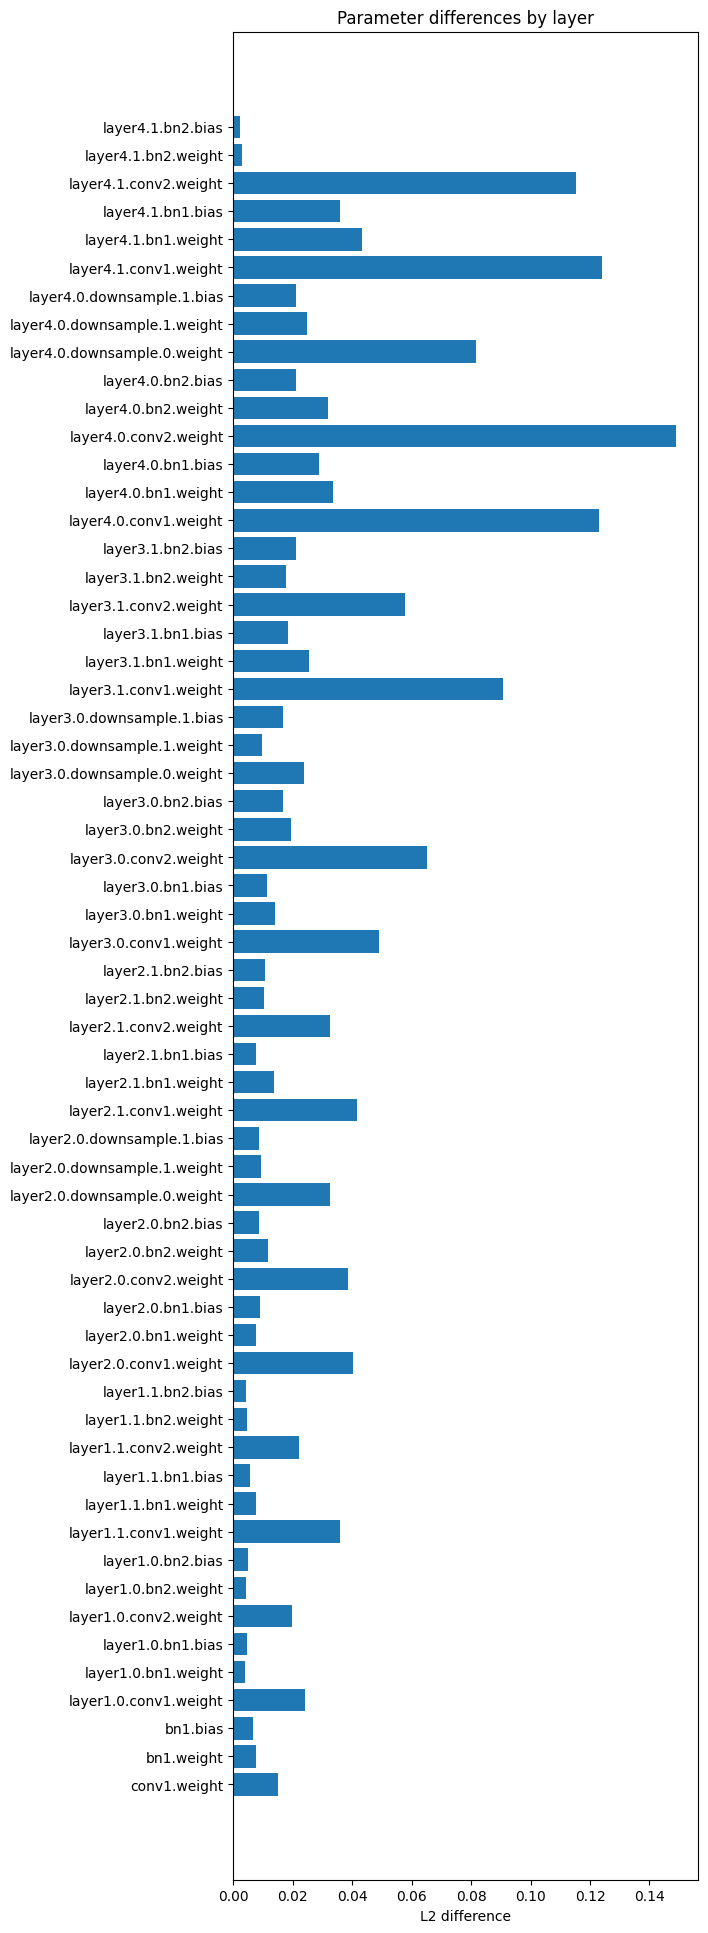

In [20]:

layer_names = list(diffs_l.keys())
layer_values = [diffs_l[k] for k in layer_names]

plt.figure(figsize=(6,24))
plt.barh(layer_names, layer_values)
plt.xlabel("L2 difference")
plt.title("Parameter differences by layer")
plt.show()